# Comparação estatística de datasets para Retinopatia Diabética

## Objetivo da atividade

Desenvolver habilidades práticas de seleção, limpeza, análise estatística e visualização de dados aplicadas à oftalmologia, utilizando dados públicos e métodos estatísticos.

## Objetivo deste notebook

Este notebook realiza uma comparação estrutural e estatística de datasets relacionados à Retinopatia Diabética (RD), com o objetivo de selecionar de forma transparente e reproduzível o conjunto de dados mais adequado à análise principal da disciplina.

Todos os datasets são submetidos, quando seus arquivos tabulares estão acessíveis, à mesma rotina de inspeção:

- dimensionalidade;
- número de pacientes identificáveis;
- tipos de variáveis;
- valores ausentes;
- duplicatas;
- variabilidade das variáveis numéricas;
- disponibilidade de variáveis clínicas e demográficas;
- disponibilidade de variáveis adequadas para correlação;
- existência de grupos comparáveis;
- existência de desfecho relacionado à RD;
- disponibilidade de classificação de gravidade da RD.

O resultado desta etapa fundamentará a seleção de um único dataset para a análise principal, desenvolvida no notebook `01_diabetic_retinopathy_analysis.ipynb`.

## Princípio de comparação

O objetivo é identificar qual dataset apresenta a estrutura mais adequada aos requisitos estatísticos da atividade.

Entre os principais requisitos estão:

1. estatística descritiva de variáveis numéricas;
2. frequências de variáveis categóricas;
3. caracterização da população;
4. correlação entre duas variáveis numéricas;
5. comparação de uma variável entre dois ou mais grupos;
6. interpretação dos resultados considerando seu significado clínico.

Por isso, um dataset com muitas variáveis numéricas derivadas de imagens pode ser conveniente para determinadas análises, mas menos adequado para a caracterização clínica do que uma base que contenha informações como idade, sexo, duração do diabetes, comorbidades e estágio da RD.

Também é considerada a unidade de análise. Dependendo do dataset, cada linha pode representar um paciente, um olho, uma imagem ou outra unidade de observação. Por esse motivo, número de registros e número de pacientes não são tratados como equivalentes.

## Datasets candidatos

Foram considerados:

- **[mBRSET — Mobile Brazilian Retinal Dataset](https://physionet.org/content/mbrset/1.0/)**
- **[BRSET — Brazilian Multilabel Ophthalmological Dataset](https://physionet.org/content/brazilian-ophthalmological/1.0.2/)**
- **[Diabetic Retinopathy Debrecen](https://archive.ics.uci.edu/dataset/329/diabetic)**
- **[DRS — Diabetic Retinopathy Study](https://vincentarelbundock.github.io/Rdatasets/doc/survival/retinopathy.html)**
- **[ODIR-5K — Ocular Disease Intelligent Recognition](https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k)**
- **[CMRDD — Comprehensive Multimodal Retinal Disorder Diagnosis Dataset](https://www.kaggle.com/datasets/datasetengineer/multimodal-retinal-disorder-diagnosis-dataset)**

BRSET e mBRSET são carregados diretamente dos repositórios públicos dos próprios autores no GitHub. Para ODIR-5K e CMRDD, o notebook tenta baixar somente os arquivos tabulares pelo Kaggle, evitando o download das imagens.

In [1]:
%pip -q install ucimlrepo kagglehub openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re

from pathlib import Path
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns",120)
plt.rcParams["figure.dpi"] = 110

# 1. Fontes dos dados

As URLs utilizadas no notebook são centralizadas para facilitar a auditoria e a reprodução das análises.

Para o BRSET e o mBRSET, foram utilizados os arquivos CSV disponibilizados publicamente nos repositórios GitHub mantidos pelos próprios autores dos datasets.

In [3]:
URLS = {
    "mBRSET": "https://raw.githubusercontent.com/luisnakayama/mBRSET/main/dataframe_brsetmobile.csv",
    "BRSET": "https://raw.githubusercontent.com/luisnakayama/BRSET/main/data/labels.csv",
    "DRS": "https://vincentarelbundock.github.io/Rdatasets/csv/survival/retinopathy.csv",
}

KAGGLE_FILES = {
    "ODIR-5K": {
        "handle": "andrewmvd/ocular-disease-recognition-odir5k",
        "url": "https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k",
        "files": ["full_df.csv","ODIR-5K_Training_Annotations(Updated)_V2.xlsx"],
    },

    "CMRDD": {
        "handle": "datasetengineer/multimodal-retinal-disorder-diagnosis-dataset",
        "url": "https://www.kaggle.com/datasets/datasetengineer/multimodal-retinal-disorder-diagnosis-dataset",
        "files": ["retinal_disorders_dataset.csv"],
    },
}

# 2. Funções auxiliares

Os nomes das colunas são normalizados para snake_case, permitindo comparar bases que utilizam convenções distintas.

No BRSET, o CSV público do GitHub possui nomes como diabetes_time_y, insuline, iluminaton e drusens. O notebook cria aliases padronizados apenas para a análise, sem alterar o arquivo original.

In [4]:
def normalize_name(name):
    name = str(name).replace("\ufeff","").strip()
    name = re.sub(r"[^A-Za-z0-9]+","_",name)
    name = re.sub(r"_+","_",name).strip("_").lower()
    return name

def normalize_columns(df):
    out = df.copy()
    out.columns = [normalize_name(c) for c in out.columns]

    if out.columns.duplicated().any():
        duplicated = out.columns[out.columns.duplicated()].tolist()
        raise ValueError(f"Colunas duplicadas após normalização: {duplicated}")

    aliases = {
        "diabetes_time_y": "diabetes_time",
        "insuline": "insulin_use",
        "iluminaton": "illumination",
        "drusens": "drusen",
        "rownames": "row_id",
    }

    rename = {old: new for old, new in aliases.items() if old in out.columns and new not in out.columns}

    return out.rename(columns=rename)

def existing(df,columns):
    return [c for c in columns if c in df.columns]

def match_columns(df,patterns):
    found = []

    for col in df.columns:
        for pattern in patterns:
            if re.search(pattern,col,flags=re.IGNORECASE):
                found.append(col)
                break

    return sorted(set(found))

def first_existing(df,candidates):
    for c in candidates:
        if c in df.columns:
            return c

    return None

In [5]:
def load_kaggle_table(handle,candidate_files):
    try:
        import kagglehub
    except ImportError:
        return None,"kagglehub não instalado, suba o notebook e baixe"

    errors = []

    for filename in candidate_files:
        try:
            path = Path(kagglehub.dataset_download(handle,path=filename,))

            if filename.lower().endswith(".csv"):
                return pd.read_csv(path),str(path)

            if filename.lower().endswith((".xlsx",".xls")):
                return pd.read_excel(path),str(path)

        except Exception as exc:
            errors.append(f"{filename}: {type(exc).__name__}: {exc}")

    return None," | ".join(errors)

# 3. Carregamento dos datasets

In [6]:
datasets = {}
load_log = {}

# mBRSET https://github.com/luisnakayama/mBRSET

try:
    df = pd.read_csv(URLS["mBRSET"])
    datasets["mBRSET"] = normalize_columns(df)
    load_log["mBRSET"] = f"OK {df.shape[0]} linhas × {df.shape[1]} colunas"

except Exception as exc:
    load_log["mBRSET"] = f"ERRO {type(exc).__name__}: {exc}"

# BRSET https://github.com/luisnakayama/BRSET

try:
    df = pd.read_csv(URLS["BRSET"])
    df = normalize_columns(df)

    if "diabetes_time" in df.columns:
        df["diabetes_time"] = pd.to_numeric(df["diabetes_time"],errors="coerce",)

    datasets["BRSET"] = df
    load_log["BRSET"] = f"OK {df.shape[0]} linhas × {df.shape[1]} colunas"

except Exception as exc:
    load_log["BRSET"] = f"ERRO {type(exc).__name__}: {exc}"

# Debrecen https://archive.ics.uci.edu/dataset/329/diabetic

try:
    uci = fetch_ucirepo(id=329)

    X = uci.data.features.copy().reset_index(drop=True)
    y = uci.data.targets.copy().reset_index(drop=True)

    debrecen_feature_names = [
        "quality","pre_screening","ma1","ma2","ma3","ma4","ma5","ma6",
        "exudate1","exudate2","exudate3","exudate4","exudate5","exudate6",
        "exudate7","exudate8","macula_opticdisc_distance","opticdisc_diameter","am_fm_classification",
    ]

    if X.shape[1] != 19 or y.shape[1] != 1:
        raise ValueError("Estrutura inesperada no dataset Debrecen.")

    X.columns = debrecen_feature_names
    y.columns = ["label"]

    df = pd.concat([X,y],axis=1,)
    datasets["Debrecen"] = df
    load_log["Debrecen"] = f"OK {df.shape[0]} linhas × {df.shape[1]} colunas"

except Exception as exc:
    load_log["Debrecen"] = f"ERRO {type(exc).__name__}: {exc}"

# DRS https://vincentarelbundock.github.io/Rdatasets/doc/survival/retinopathy.html

try:
    df = pd.read_csv(URLS["DRS"])
    df = normalize_columns(df)

    if "row_id" in df.columns:
        df = df.drop(columns="row_id")

    datasets["DRS"] = df
    load_log["DRS"] = f"OK {df.shape[0]} linhas × {df.shape[1]} colunas"

except Exception as exc:
    load_log["DRS"] = f"ERRO {type(exc).__name__}: {exc}"

# ODIR-5K https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k

odir_cfg = KAGGLE_FILES["ODIR-5K"]
df,msg = load_kaggle_table(odir_cfg["handle"],odir_cfg["files"],)

if df is not None:
    datasets["ODIR-5K"] = normalize_columns(df)
    load_log["ODIR-5K"] = f"OK {df.shape[0]} linhas × {df.shape[1]} colunas {msg}"
else:
    load_log["ODIR-5K"] = f"NÃO CARREGADO {msg}"

# CMRDD https://www.kaggle.com/datasets/datasetengineer/multimodal-retinal-disorder-diagnosis-dataset

cmrdd_cfg = KAGGLE_FILES["CMRDD"]
df,msg = load_kaggle_table(cmrdd_cfg["handle"],cmrdd_cfg["files"],)

if df is not None:
    datasets["CMRDD"] = normalize_columns(df)
    load_log["CMRDD"] = f"OK {df.shape[0]} linhas × {df.shape[1]} colunas {msg}"
else:
    load_log["CMRDD"] = f"NÃO CARREGADO {msg}"

display(pd.DataFrame.from_dict(load_log,orient="index",columns=["status"],))

,status
mBRSET,OK 5164 linhas × 24 colunas
BRSET,OK 16266 linhas × 34 colunas
Debrecen,OK 1151 linhas × 20 colunas
DRS,OK 394 linhas × 9 colunas
ODIR-5K,OK 6392 linhas × 19 colunas /home/ari/.cache/k...
CMRDD,OK 283893 linhas × 37 colunas /home/ari/.cache...


# 4. Definição semântica das variáveis

Uma comparação baseada apenas no número de colunas seria inadequada, pois os datasets possuem variáveis com funções e significados diferentes.

As variáveis são separadas em:

- numéricas clinicamente interpretáveis;
- clínicas categóricas estruturadas;
- demográficas;
- variáveis de agrupamento;
- desfechos relacionados à RD.

O Debrecen é um caso bem especifico, pois seus 19 atributos são representados numericamente, mas correspondem principalmente a características extraídas de imagens, sem ter as variáveis clínicas ou demográficas dos pacientes.

In [7]:
SCHEMA = {
    "mBRSET": {
        "patient_id": ["patient"],
        "clinical_numeric": ["age","dm_time","insulin_time"],
        "clinical_categorical": [
            "insulin","oraltreatment_dm","systemic_hypertension",
            "alcohol_consumption","smoking","obesity",
            "vascular_disease","acute_myocardial_infarction",
            "nephropathy","neuropathy","diabetic_foot",
        ],
        "demographic": ["age","sex","educational_level"],
        "group_variables": [
            "sex","insulin","oraltreatment_dm",
            "systemic_hypertension","smoking","obesity",
            "final_icdr","final_edema",
        ],
        "outcomes": ["final_icdr","final_edema"],
        "dr_specific_outcome": True,
        "dr_severity": True,
    },

    "BRSET": {
        "patient_id": ["patient_id"],
        "clinical_numeric": ["patient_age","diabetes_time"],
        "clinical_categorical": ["diabetes","insulin_use"],
        "demographic": ["patient_age","patient_sex","nationality"],
        "group_variables": [
            "patient_sex","diabetes","insulin_use",
            "dr_icdr","dr_sdrg","diabetic_retinopathy","macular_edema",
        ],
        "outcomes": ["dr_icdr","dr_sdrg","diabetic_retinopathy","macular_edema"],
        "dr_specific_outcome": True,
        "dr_severity": True,
    },

    "Debrecen": {
        "patient_id": [],
        "clinical_numeric": [],
        "clinical_categorical": [],
        "demographic": [],
        "group_variables": ["label"],
        "outcomes": ["label"],
        "dr_specific_outcome": True,
        "dr_severity": False,
    },

    "DRS": {
        "patient_id": ["id"],
        "clinical_numeric": ["age","risk"],
        "clinical_categorical": ["laser","type","trt"],
        "demographic": ["age"],
        "group_variables": ["laser","type","trt","status"],
        "outcomes": ["futime","status"],
        "dr_specific_outcome": True,
        "dr_severity": False,
    },

    "ODIR-5K": {
        "patient_id": ["id"],
        "clinical_numeric": ["patient_age"],
        "clinical_categorical": [],
        "demographic": ["patient_age","patient_sex"],
        "group_variables": ["patient_sex","d"],
        "outcomes": ["d"],
        "dr_specific_outcome": False,
        "dr_severity": False,
    },
}

In [8]:
CMRDD_PATTERNS = {
    "patient_id": [r"^patient_id$",r"^patient$"],
    "clinical_numeric": [
        r"^age$",r"systolic",r"diastolic",r"bmi",
        r"glucose",r"hba1c",r"diabetes.*duration",
        r"visual.*acuity",r"intraocular.*pressure",r"^iop$",
    ],
    "clinical_categorical": [
        r"^gender$",r"hypertension",r"cardiovascular",
        r"smoking",r"family.*history",r"medication",r"^ethnicity$",
    ],
    "demographic": [r"^age$",r"^gender$",r"^sex$",r"^ethnicity$"],
    "outcomes": [r"retinal.*disorder",r"diagnos",r"target",r"label",r"classification"],
}

def build_cmrdd_schema(df):
    schema = {key: match_columns(df,patterns) for key, patterns in CMRDD_PATTERNS.items()}

    schema["group_variables"] = list(dict.fromkeys(schema["clinical_categorical"] + schema["outcomes"]))
    schema["dr_specific_outcome"] = "retinal_disorder" in schema["outcomes"]
    schema["dr_severity"] = False

    return schema

if "CMRDD" in datasets:
    SCHEMA["CMRDD"] = build_cmrdd_schema(datasets["CMRDD"])

# 5. Inspeção estatística padronizada

Para todos os datasets carregados são calculadas as mesmas medidas:

- número de registros e colunas;
- número de pacientes identificáveis;
- registros por paciente;
- percentual de células ausentes;
- percentual de duplicatas exatas;
- número de variáveis numéricas;
- número de variáveis numéricas não constantes;
- número de variáveis clínicas numéricas e categóricas;
- número de variáveis demográficas;
- número de variáveis de agrupamento válidas;
- quantidade de pares de variáveis clínicas disponíveis para correlação;
- quantidade de desfechos identificados;
- presença de identificador de paciente;
- presença de desfecho relacionado à Retinopatia Diabética;
- presença de classificação de gravidade da Retinopatia Diabética.

In [9]:
def structural_summary(name,df,schema):
    n_rows,n_cols = df.shape

    patient_col = first_existing(df,schema.get("patient_id",[]),)

    if patient_col:
        n_patients = int(df[patient_col].nunique(dropna=True))
        rows_per_patient = n_rows / n_patients if n_patients > 0 else np.nan
    else:
        n_patients = np.nan
        rows_per_patient = np.nan

    missing_total = int(df.isna().sum().sum())

    total_cells = n_rows * n_cols
    missing_pct = 100 * missing_total / total_cells if total_cells else np.nan

    duplicate_rows = int(df.duplicated().sum())

    duplicate_pct = 100 * duplicate_rows / n_rows if n_rows else np.nan

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    nonconstant_numeric = [c for c in numeric_cols if df[c].nunique(dropna=True) > 1]

    clinical_numeric = [
        c for c in existing(df,schema.get("clinical_numeric",[]),)
        if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) > 1
        ]

    clinical_categorical = existing(df,schema.get("clinical_categorical",[]),)
    demographic = existing(df,schema.get("demographic",[]),)
    group_variables = existing(df,schema.get("group_variables",[]),)
    valid_groups = [c for c in group_variables if df[c].nunique(dropna=True) >= 2]
    outcomes = existing(df,schema.get("outcomes",[]),)

    n_corr_pairs = comb(len(clinical_numeric),2) if len(clinical_numeric) >= 2 else 0

    return {
        "dataset": name,
        "registros": n_rows,
        "colunas": n_cols,
        "pacientes_identificados": n_patients,
        "registros_por_paciente": rows_per_patient,
        "ausentes_pct": missing_pct,
        "duplicatas_pct": duplicate_pct,
        "numericas_total": len(numeric_cols),
        "numericas_nao_constantes": len(nonconstant_numeric),
        "numericas_clinicas": len(clinical_numeric),
        "clinicas_categoricas": len(clinical_categorical),
        "demograficas": len(demographic),
        "grupos_validos": len(valid_groups),
        "pares_correlacao_clinica": n_corr_pairs,
        "desfechos_identificados": len(outcomes),
        "tem_patient_id": patient_col is not None,
        "tem_desfecho_rd": bool(schema.get("dr_specific_outcome",False,)),
        "tem_estagio_rd": bool(schema.get("dr_severity",False,)),
    }

In [10]:
summaries = []

for name, df in datasets.items():
    if name not in SCHEMA:
        print(f"{name}: sem schema semântico; não foi incluído na comparação.")
        continue

    summaries.append(structural_summary(name,df,SCHEMA[name],))

df_summary = pd.DataFrame(summaries).set_index("dataset").sort_index()

display(df_summary.round({"registros_por_paciente": 3,"ausentes_pct": 3,"duplicatas_pct": 3,}))

,registros,colunas,pacientes_identificados,registros_por_paciente,ausentes_pct,duplicatas_pct,numericas_total,numericas_nao_constantes,numericas_clinicas,clinicas_categoricas,demograficas,grupos_validos,pares_correlacao_clinica,desfechos_identificados,tem_patient_id,tem_desfecho_rd,tem_estagio_rd
dataset,,,,,,,,,,,,,,,,,
BRSET,16266,34,8524.0,1.908,7.709,0.000,26,26,2,2,3,7,1,4,True,True,True
CMRDD,283893,37,283893.0,1.000,1.354,0.000,28,28,8,6,3,7,28,1,True,True,False
DRS,394,9,197.0,2.000,0.000,0.000,6,6,2,3,1,4,1,2,True,True,False
Debrecen,1151,20,NaN,NaN,0.000,0.434,20,20,0,0,0,1,0,1,False,True,False
ODIR-5K,6392,19,3358.0,1.904,0.000,0.000,10,10,1,0,2,2,0,1,True,False,False
mBRSET,5164,24,1291.0,4.000,4.558,0.000,19,19,3,11,3,8,3,2,True,True,True


## 5.1. Valores ausentes por variável

A presença de valores ausentes não é tratada automaticamente como um problema de qualidade. A análise serve para identificar quais variáveis exigem maior atenção durante o pré-processamento e verificar se as ausências podem estar relacionadas à própria estrutura dos dados.

In [11]:
missing_tables = {}

for name, df in datasets.items():
    table = pd.DataFrame(
        {"n_ausentes": df.isna().sum(),"pct_ausentes": df.isna().mean() * 100,}
        ).query(
            "n_ausentes > 0").sort_values(
                "pct_ausentes",ascending=False,)

    missing_tables[name] = table

    print(f"\n{name}")

    if table.empty:
        print("Nenhum valor ausente identificado.")
    else:
        display(table.head(15).round(3))


mBRSET


,n_ausentes,pct_ausentes
insulin_time,4148,80.325
final_icdr,280,5.422
final_edema,265,5.132
diabetic_foot,108,2.091
smoking,88,1.704
acute_myocardial_infarction,84,1.627
nephropathy,80,1.549
obesity,76,1.472
alcohol_consumption,76,1.472
neuropathy,76,1.472



BRSET


,n_ausentes,pct_ausentes
insulin_use,14552,89.463
diabetes_time,14402,88.541
comorbidities,8236,50.633
patient_age,5445,33.475



Debrecen
Nenhum valor ausente identificado.

DRS
Nenhum valor ausente identificado.

ODIR-5K
Nenhum valor ausente identificado.

CMRDD


,n_ausentes,pct_ausentes
medications,142206,50.091


## 5.2. Variabilidade das variáveis numéricas

São apresentados média, mediana, desvio-padrão, amplitude e número de valores distintos. Essas medidas ajudam a verificar a distribuição e a variabilidade das variáveis numéricas. Variáveis sem variação não contribuem para análises de correlação ou comparação entre grupos.

In [12]:
numeric_profiles = {}

for name, df in datasets.items():
    id_cols = existing(df,SCHEMA.get(name,{}).get("patient_id",[]),)

    numeric = df.select_dtypes(include=np.number).drop(columns=id_cols,errors="ignore")

    if numeric.empty:
        continue

    profile = pd.DataFrame({
        "n": numeric.count(),
        "n_unique": numeric.nunique(dropna=True),
        "media": numeric.mean(),
        "mediana": numeric.median(),
        "desvio_padrao": numeric.std(),
        "min": numeric.min(),
        "max": numeric.max(),
    })

    profile["amplitude"] = profile["max"] - profile["min"]
    numeric_profiles[name] = profile

    print(f"\n{name}")
    display(profile.sort_values(["n_unique","desvio_padrao"],ascending=False,).head(15).round(3))


mBRSET


,n,n_unique,media,mediana,desvio_padrao,min,max,amplitude
age,5164,71,61.448,63.0,11.634,3.0,110.0,107.0
dm_time,5108,42,9.541,7.0,8.639,0.0,83.0,83.0
insulin_time,1016,32,7.942,5.0,8.304,0.0,50.0,50.0
educational_level,5112,7,3.017,2.0,1.651,1.0,7.0,6.0
final_icdr,4884,5,0.512,0.0,1.051,0.0,4.0,4.0
sex,5164,2,0.349,0.0,0.477,0.0,1.0,1.0
systemic_hypertension,5120,2,0.714,1.0,0.452,0.0,1.0,1.0
insulin,5116,2,0.208,0.0,0.406,0.0,1.0,1.0
vascular_disease,5088,2,0.171,0.0,0.376,0.0,1.0,1.0
oraltreatment_dm,5120,2,0.846,1.0,0.361,0.0,1.0,1.0



BRSET


,n,n_unique,media,mediana,desvio_padrao,min,max,amplitude
patient_age,10821,92,57.656,61.0,18.260,5.0,97.0,92.0
diabetes_time,1864,45,13.122,10.0,9.593,1.0,60.0,59.0
dr_sdrg,16266,5,0.181,0.0,0.750,0.0,4.0,4.0
dr_icdr,16266,5,0.180,0.0,0.739,0.0,4.0,4.0
exam_eye,16266,2,1.499,1.0,0.500,1.0,2.0,1.0
patient_sex,16266,2,1.618,2.0,0.486,1.0,2.0,1.0
macula,16266,2,1.288,1.0,0.453,1.0,2.0,1.0
increased_cup_disc,16266,2,0.197,0.0,0.398,0.0,1.0,1.0
drusen,16266,2,0.173,0.0,0.378,0.0,1.0,1.0
image_field,16266,2,1.086,1.0,0.281,1.0,2.0,1.0



Debrecen


...

,n,n_unique,media,mediana,desvio_padrao,min,max,amplitude
futime,394,269,35.579,38.8,21.356,0.3,74.97,74.67
age,394,54,20.782,16.0,14.812,1.0,58.00,57.00
risk,394,6,9.698,10.0,1.475,6.0,12.00,6.00
trt,394,2,0.500,0.5,0.501,0.0,1.00,1.00
status,394,2,0.393,0.0,0.489,0.0,1.00,1.00



ODIR-5K


,n,n_unique,media,mediana,desvio_padrao,min,max,amplitude
patient_age,6392,75,57.858,59.0,11.728,1,91,90
d,6392,2,0.332,0.0,0.471,0,1,1
n,6392,2,0.329,0.0,0.470,0,1,1
o,6392,2,0.248,0.0,0.432,0,1,1
c,6392,2,0.063,0.0,0.243,0,1,1
g,6392,2,0.062,0.0,0.241,0,1,1
a,6392,2,0.050,0.0,0.218,0,1,1
m,6392,2,0.048,0.0,0.214,0,1,1
h,6392,2,0.032,0.0,0.175,0,1,1



CMRDD


,n,n_unique,media,mediana,desvio_padrao,min,max,amplitude
texture_glcm_contrast,283893,283893,2.002,1.681,1.416,0.002,15.536,15.534
deep_feature_1,283893,283893,-0.002,-0.004,1.002,-4.708,4.581,9.289
deep_feature_2,283893,283893,0.003,0.001,1.001,-4.710,4.634,9.344
deep_feature_3,283893,283893,0.002,0.000,1.000,-4.323,4.668,8.991
vessel_tortuosity,283893,283893,0.400,0.277,0.401,0.000,5.132,5.132
texture_gabor_response,283893,283893,0.600,0.614,0.200,0.017,1.000,0.983
cup_to_disc_ratio,283893,283893,0.286,0.265,0.160,0.000,0.939,0.939
bifurcation_angle,283893,283839,75.009,74.991,9.978,40.000,118.674,78.674
optic_disc_area,283893,283694,2.100,2.100,0.500,0.500,4.381,3.881
macular_thickness,283893,282992,280.087,280.016,24.943,200.000,350.000,150.000


# 6. Desfechos e grupos

A distribuição de um desfecho categórico de cada dataset é apresentada para verificar a quantidade de categorias, o desbalanceamento e a disponibilidade de grupos.

In [13]:
def show_outcome_distribution(name,df,schema,):
    outcomes = existing(df,schema.get("outcomes",[]),)
    outcome = next((c for c in outcomes if 2 <= df[c].nunique(dropna=True) <= 20),None)

    if outcome is None:
        print(f"{name}: nenhum desfecho categórico identificado.")
        return

    counts = df[outcome].value_counts(dropna=False)
    pct = df[outcome].value_counts(dropna=False,normalize=True,) * 100
    table = pd.DataFrame({"n": counts,"pct": pct,})

    print(f"\n{name}: desfecho: {outcome}")
    display(table.round(2))

for name, df in datasets.items():
    if name in SCHEMA:
        show_outcome_distribution(name,df,SCHEMA[name],)


mBRSET: desfecho: final_icdr


,n,pct
final_icdr,,
0.0,3750,72.62
2.0,568,11.00
NaN,280,5.42
1.0,272,5.27
4.0,212,4.11
3.0,82,1.59



BRSET: desfecho: dr_icdr


,n,pct
dr_icdr,,
0,15210,93.51
4,394,2.42
2,310,1.91
3,190,1.17
1,162,1.00



Debrecen: desfecho: label


...

,n,pct
status,,
0,239,60.66
1,155,39.34



ODIR-5K: desfecho: d


,n,pct
d,,
0,4269,66.79
1,2123,33.21



CMRDD: desfecho: retinal_disorder


,n,pct
retinal_disorder,,
0,141762,49.94
1,71070,25.03
2,28503,10.04
3,22552,7.94
4,11582,4.08
5,8424,2.97


# 7. Matriz objetiva de compatibilidade

A matriz abaixo não usa pesos.

Cada coluna responde a uma pergunta objetiva:

- Descritiva numérica: existe variável numérica não constante?
- Frequências categóricas: existe variável categórica ou de grupo com mais de um nível?
- Correlação clínica: existem pelo menos duas variáveis numéricas clinicamente/demograficamente interpretáveis?
- Comparação entre grupos: existe variável numérica interpretável e pelo menos um agrupamento válido?
- Caracterização populacional: existem pelo menos duas variáveis demográficas estruturadas?
- Desfecho RD: existe desfecho diretamente relacionado ao problema?
- Estágio RD: existe classificação padronizada/ordinal de gravidade da RD?

A parte de requisitos atendidos é a contagem dos seis requisitos centrais e estagio_rd é mantido separadamente. O enunciado recomenda estágio quando disponível e porque ele é especialmente útil para o problema escolhido.

In [14]:
def requirement_matrix_row(name,df,schema,):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    numeric_nonconstant = [c for c in numeric_cols if df[c].nunique(dropna=True) > 1]

    clinical_numeric = [
        c for c in existing(df,schema.get("clinical_numeric",[]),)
        if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) > 1
    ]

    demographic = existing(df,schema.get("demographic",[]),)

    group_variables = existing(df,schema.get("group_variables",[]),)

    valid_group_variables = [c for c in group_variables if df[c].nunique(dropna=True) >= 2]

    descriptive = len(numeric_nonconstant) >= 1

    categorical_frequency = len(valid_group_variables) >= 1

    clinical_correlation = len(clinical_numeric) >= 2

    clinical_group_comparison = (len(clinical_numeric) >= 1 and len(valid_group_variables) >= 1)

    population_characterization = len(demographic) >= 2

    dr_outcome = bool(schema.get("dr_specific_outcome",False,))

    dr_stage = bool(schema.get("dr_severity",False,))

    required = {
        "descritiva_numerica": descriptive,
        "frequencias_categoricas": categorical_frequency,
        "correlacao_clinica": clinical_correlation,
        "comparacao_grupos": clinical_group_comparison,
        "caracterizacao_populacao": population_characterization,
        "desfecho_rd": dr_outcome,
    }

    return {
        "dataset": name,
        **required,
        "estagio_rd": dr_stage,
        "requisitos_atendidos": int(sum(required.values())),
        "total_requisitos": len(required),
        "cobertura_pct": 100 * sum(required.values()) / len(required),
    }


requirements = []

for name, df in datasets.items():
    if name in SCHEMA:
        requirements.append(requirement_matrix_row(name,df,SCHEMA[name],))

df_requirements = pd.DataFrame(requirements).set_index("dataset")

display(df_requirements)

,descritiva_numerica,frequencias_categoricas,correlacao_clinica,comparacao_grupos,caracterizacao_populacao,desfecho_rd,estagio_rd,requisitos_atendidos,total_requisitos,cobertura_pct
dataset,,,,,,,,,,
mBRSET,True,True,True,True,True,True,True,6,6,100.000000
BRSET,True,True,True,True,True,True,True,6,6,100.000000
Debrecen,True,True,False,False,False,True,False,3,6,50.000000
DRS,True,True,True,True,False,True,False,5,6,83.333333
ODIR-5K,True,True,False,True,True,False,False,4,6,66.666667
CMRDD,True,True,True,True,True,True,False,6,6,100.000000


# 8. Seleção sem matriz ponderada

A seleção é feita em três etapas.

## Etapa 1: elegibilidade científica

Primeiro, são considerados para a seleção final apenas datasets com proveniência científica ou institucional verificável. Datasets sem documentação científica independente suficiente permanecem na comparação exploratória, mas optei por não disputarem a seleção final.

## Etapa 2: cobertura dos requisitos

Dentre os datasets elegíveis, prioriza-se aquele que atende ao maior número dos seis requisitos centrais da atividade.

## Etapa 3: desempate objetivo

Se houver empate na cobertura, são aplicados sucessivamente:

1. presença de estágio/gravidade padronizada da RD;
2. maior número de pares disponíveis para correlação clínica;
3. maior número de variáveis de agrupamento válidas;
4. maior número de variáveis clínicas estruturadas;
5. maior número de variáveis demográficas;
6. maior número de pacientes identificáveis.

In [15]:
SCIENTIFIC_ELIGIBILITY = {
    "mBRSET": True,
    "BRSET": True,
    "Debrecen": True,
    "DRS": True,
    "ODIR-5K": True,
    "CMRDD": False,
}

selection = df_requirements[
    [
        "requisitos_atendidos",
        "total_requisitos",
        "cobertura_pct",
        "estagio_rd",
    ]
].join(
    df_summary[
        [
            "numericas_clinicas",
            "clinicas_categoricas",
            "demograficas",
            "grupos_validos",
            "pares_correlacao_clinica",
            "pacientes_identificados",
            "ausentes_pct",
        ]
    ]
)

selection["variaveis_clinicas_estruturadas"] = selection["numericas_clinicas"] + selection["clinicas_categoricas"]

selection["elegivel_selecao_final"] = pd.Series(SCIENTIFIC_ELIGIBILITY).reindex(selection.index).fillna(False)

selection["pacientes_para_ordenacao"] = selection["pacientes_identificados"].fillna(0)

display(selection.drop(columns="pacientes_para_ordenacao").round(3))


ranking = selection[selection["elegivel_selecao_final"]].sort_values(
    by=[
        "requisitos_atendidos",
        "estagio_rd",
        "pares_correlacao_clinica",
        "grupos_validos",
        "variaveis_clinicas_estruturadas",
        "demograficas",
        "pacientes_para_ordenacao",
    ],
    ascending=[False,False,False,False,False,False,False],
)

print("\nRanking final entre datasets elegíveis:")

display(ranking.drop(columns="pacientes_para_ordenacao").round(3))

,requisitos_atendidos,total_requisitos,cobertura_pct,estagio_rd,numericas_clinicas,clinicas_categoricas,demograficas,grupos_validos,pares_correlacao_clinica,pacientes_identificados,ausentes_pct,variaveis_clinicas_estruturadas,elegivel_selecao_final
dataset,,,,,,,,,,,,,
mBRSET,6,6,100.000,True,3,11,3,8,3,1291.0,4.558,14,True
BRSET,6,6,100.000,True,2,2,3,7,1,8524.0,7.709,4,True
Debrecen,3,6,50.000,False,0,0,0,1,0,NaN,0.000,0,True
DRS,5,6,83.333,False,2,3,1,4,1,197.0,0.000,5,True
ODIR-5K,4,6,66.667,False,1,0,2,2,0,3358.0,0.000,1,True
CMRDD,6,6,100.000,False,8,6,3,7,28,283893.0,1.354,14,False



Ranking final entre datasets elegíveis:


,requisitos_atendidos,total_requisitos,cobertura_pct,estagio_rd,numericas_clinicas,clinicas_categoricas,demograficas,grupos_validos,pares_correlacao_clinica,pacientes_identificados,ausentes_pct,variaveis_clinicas_estruturadas,elegivel_selecao_final
dataset,,,,,,,,,,,,,
mBRSET,6,6,100.000,True,3,11,3,8,3,1291.0,4.558,14,True
BRSET,6,6,100.000,True,2,2,3,7,1,8524.0,7.709,4,True
DRS,5,6,83.333,False,2,3,1,4,1,197.0,0.000,5,True
ODIR-5K,4,6,66.667,False,1,0,2,2,0,3358.0,0.000,1,True
Debrecen,3,6,50.000,False,0,0,0,1,0,NaN,0.000,0,True


# 9. Visualizações comparativas

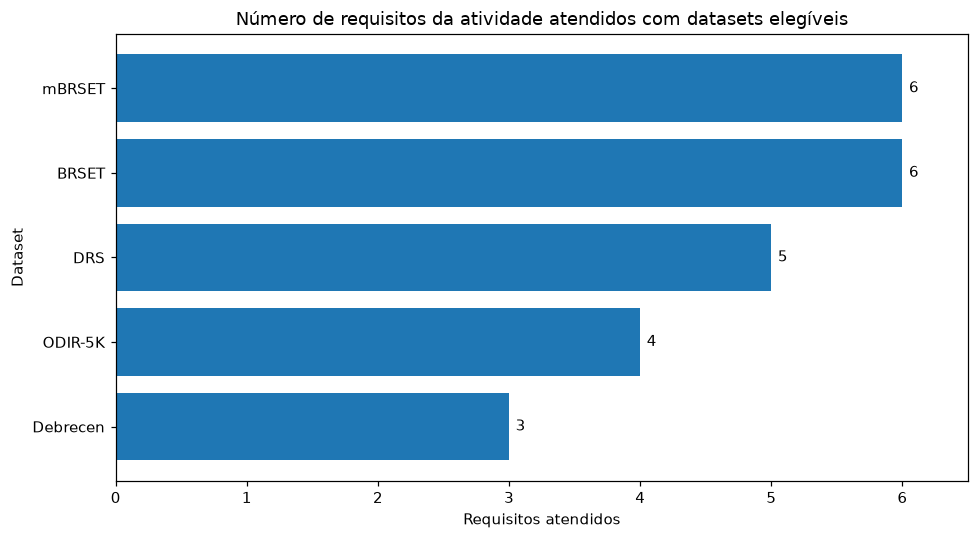

In [16]:
plot_data = ranking["requisitos_atendidos"].sort_values()

fig, ax = plt.subplots(figsize=(9,5))

ax.barh(plot_data.index,plot_data.values,)

ax.set_title("Número de requisitos da atividade atendidos com datasets elegíveis")
ax.set_xlabel("Requisitos atendidos")
ax.set_ylabel("Dataset")

max_requirements = int(df_requirements["total_requisitos"].max())
ax.set_xlim(0,max_requirements + 0.5,)

for i, value in enumerate(plot_data.values):
    ax.text(value + 0.05,i,str(int(value)),va="center",)

plt.tight_layout()
plt.show()

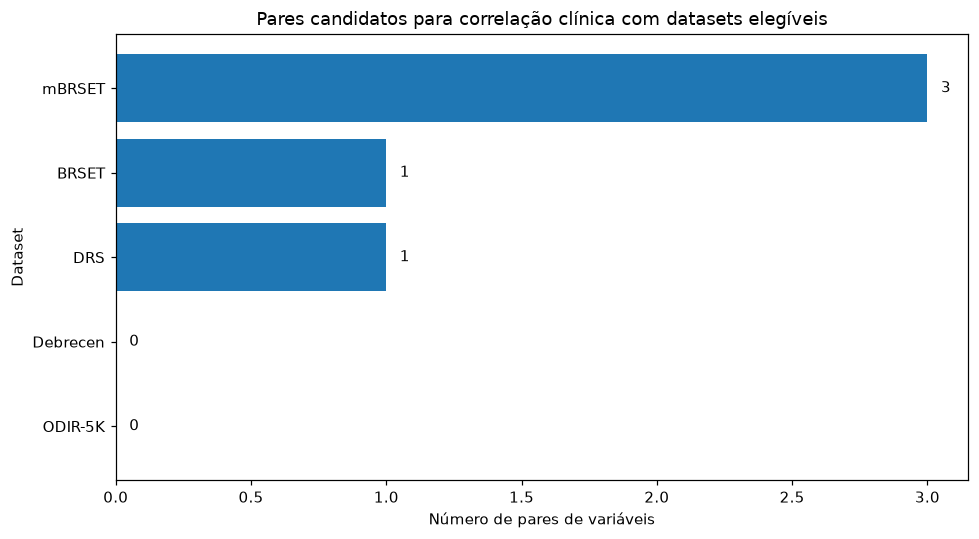

In [17]:
fig, ax = plt.subplots(figsize=(9,5))

plot_data = ranking["pares_correlacao_clinica"].sort_values()

ax.barh(plot_data.index,plot_data.values,)

ax.set_title("Pares candidatos para correlação clínica com datasets elegíveis")
ax.set_xlabel("Número de pares de variáveis")
ax.set_ylabel("Dataset")

for i, value in enumerate(plot_data.values):
    ax.text(value + 0.05,i,str(int(value)),va="center",)

plt.tight_layout()
plt.show()

In [18]:
def correlation_pair_availability(df,columns):
    rows = []

    valid_cols = [
        col for col in columns
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
        ]

    for i in range(len(valid_cols)):
        for j in range(i + 1,len(valid_cols)):
            col_x = valid_cols[i]
            col_y = valid_cols[j]

            complete = df[[col_x,col_y]].dropna()

            rows.append({
                "variavel_1": col_x,
                "variavel_2": col_y,
                "n_completo": len(complete),
                "pct_dataset": len(complete) / len(df) * 100,
            })

    return pd.DataFrame(rows)

In [19]:
for name in ranking.index:
    df = datasets[name]
    schema = SCHEMA[name]

    numeric_cols = [col for col in schema.get("clinical_numeric",[]) if col in df.columns]

    print(f"\n--- {name} ---")

    pairs = correlation_pair_availability(df,numeric_cols,)

    if pairs.empty:
        print("Não possui ao menos as duas variáveis numéricas clínicas.")
    else:
        display(pairs.sort_values("n_completo",ascending=False,).round(2))


--- mBRSET ---


,variavel_1,variavel_2,n_completo,pct_dataset
0,age,dm_time,5108,98.92
1,age,insulin_time,1016,19.67
2,dm_time,insulin_time,1016,19.67



--- BRSET ---


,variavel_1,variavel_2,n_completo,pct_dataset
0,patient_age,diabetes_time,1864,11.46



--- DRS ---


,variavel_1,variavel_2,n_completo,pct_dataset
0,age,risk,394,100.0



--- ODIR-5K ---
Não possui ao menos as duas variáveis numéricas clínicas.

--- Debrecen ---
Não possui ao menos as duas variáveis numéricas clínicas.


In [20]:
print("mBRSET: insulin × insulin_time")

display(
    pd.crosstab(datasets["mBRSET"]["insulin"],datasets["mBRSET"]["insulin_time"].notna(),margins=True,)
)

print("\nBRSET: diabetes × diabetes_time")

display(
    pd.crosstab(datasets["BRSET"]["diabetes"],datasets["BRSET"]["diabetes_time"].notna(),margins=True,)
)

mBRSET: insulin × insulin_time


insulin_time,False,True,All
insulin,,,
0.0,4052,0,4052
1.0,48,1016,1064
All,4100,1016,5116



BRSET: diabetes × diabetes_time


diabetes_time,False,True,All
diabetes,,,
no,13687,0,13687
yes,715,1864,2579
All,14402,1864,16266


### 9.1. Disponibilidade efetiva para análise de correlação

Além de contar quantos pares de variáveis poderiam ser usados em uma análise de correlação, também foi verificado quantos registros estavam disponíveis em cada combinação e como os valores ausentes se distribuíam.

No **mBRSET**, foram encontrados três pares possíveis para correlação. A combinação entre idade e duração do diabetes apresentou 5.108 registros entre os 5.164 existentes, correspondendo a 98,92% da base. Isso permite realizar essa análise com praticamente todo o conjunto de dados.

As combinações que envolvem o tempo de uso de insulina possuem 1.016 registros completos. Nesse caso, a grande quantidade de valores ausentes está relacionada principalmente à aplicabilidade da variável. Todos os 4.052 registros de pessoas que não utilizam insulina apresentam o tempo de insulinoterapia ausente, o que é esperado. Entre os 1.064 usuários de insulina, 1.016 possuem essa informação e 48 não possuem, correspondendo a aproximadamente 95,49% de completude dentro desse grupo. Há ainda 48 registros sem informação sobre o próprio uso de insulina, que não entram nessa comparação. Por esse motivo, análises envolvendo o tempo de uso de insulina devem considerar apenas os indivíduos em insulinoterapia com essa informação disponível.

No **BRSET**, a combinação entre idade e duração do diabetes possui 1.864 registros completos. Esse número corresponde a 11,46% dos 16.266 registros da base, mas o percentual deve ser interpretado considerando a população à qual essa variável se aplica. Nenhum dos 13.687 registros classificados como não diabéticos possui informação sobre duração do diabetes, o que é coerente com a própria definição da variável. Entre os 2.579 registros de pessoas com diabetes, 1.864 apresentam essa informação, correspondendo a aproximadamente 72,28% desse grupo.

No **DRS**, a combinação entre idade e risco apresentou dados completos nos 394 registros. Apesar dessa completude, o dataset possui uma estrutura de dados pareados e acompanha o tempo até a ocorrência de perda visual, apresentando um desenho diferente do foco principal desta atividade.

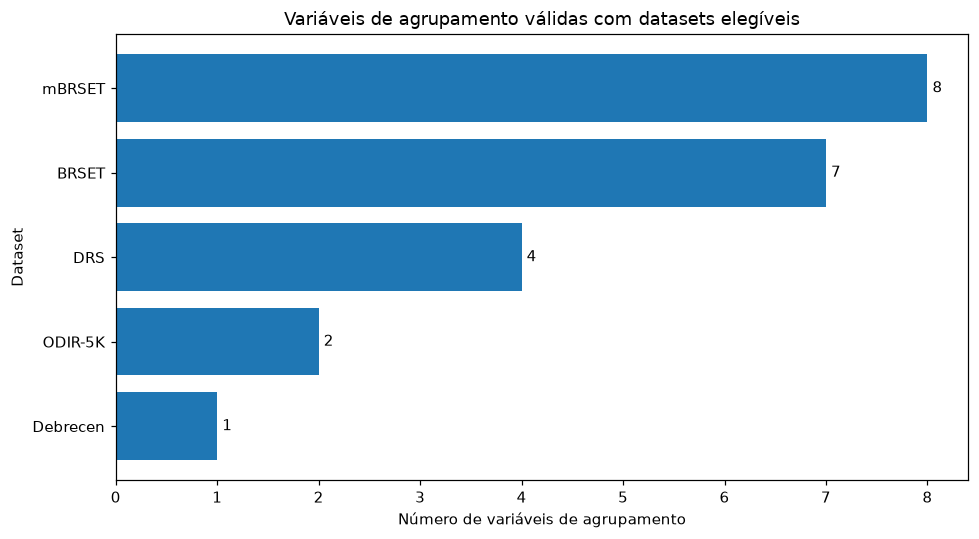

In [21]:
fig, ax = plt.subplots(figsize=(9,5))

plot_data = ranking["grupos_validos"].sort_values()

ax.barh(plot_data.index,plot_data.values,)

ax.set_title("Variáveis de agrupamento válidas com datasets elegíveis")
ax.set_xlabel("Número de variáveis de agrupamento")
ax.set_ylabel("Dataset")

for i, value in enumerate(plot_data.values):
    ax.text(value + 0.05,i,str(int(value)),va="center",)

plt.tight_layout()
plt.show()

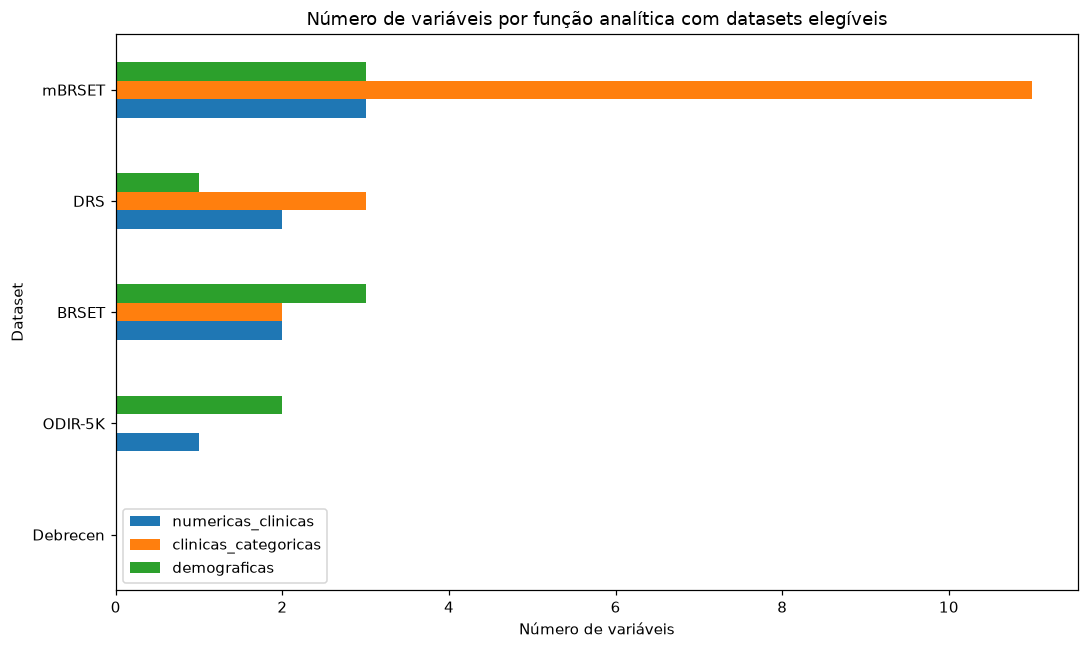

In [22]:
plot_cols = ["numericas_clinicas","clinicas_categoricas","demograficas"]

plot_data = ranking.sort_values("variaveis_clinicas_estruturadas")[plot_cols]

ax = plot_data.plot(kind="barh",figsize=(10,6),)

ax.set_title("Número de variáveis por função analítica com datasets elegíveis")
ax.set_xlabel("Número de variáveis")
ax.set_ylabel("Dataset")

plt.tight_layout()
plt.show()

# 10. Resultado automático

A célula abaixo apresenta o dataset selecionado após a aplicação dos critérios de comparação e desempate.

In [23]:
winner = ranking.index[0]
winner_row = ranking.loc[winner]

max_coverage = ranking["requisitos_atendidos"].max()
ties = ranking[ranking["requisitos_atendidos"] == max_coverage].index.tolist()

print("Dataset mais adequado segundo a triagem")
print(f"Selecionado: {winner}")
print(f"Requisitos atendidos: {int(winner_row['requisitos_atendidos'])}/{int(winner_row['total_requisitos'])}")
print(f"Cobertura: {winner_row['cobertura_pct']:.1f}%")
print(f"Estágio de RD: {'Sim' if winner_row['estagio_rd'] else 'Não'}")
print(f"Pares para correlação clínica: {int(winner_row['pares_correlacao_clinica'])}")
print(f"Variáveis de agrupamento: {int(winner_row['grupos_validos'])}")
print(f"Variáveis clínicas estruturadas: {int(winner_row['variaveis_clinicas_estruturadas'])}")
print(f"Variáveis demográficas: {int(winner_row['demograficas'])}")
print(f"Empate na cobertura: {', '.join(ties)}")

Dataset mais adequado segundo a triagem
Selecionado: mBRSET
Requisitos atendidos: 6/6
Cobertura: 100.0%
Estágio de RD: Sim
Pares para correlação clínica: 3
Variáveis de agrupamento: 8
Variáveis clínicas estruturadas: 14
Variáveis demográficas: 3
Empate na cobertura: mBRSET, BRSET


# 11. Variáveis que justificam a escolha

In [24]:
winner_df = datasets[winner]
winner_schema = SCHEMA[winner]

winner_details = {
    "Variáveis numéricas clínicas": existing(winner_df,winner_schema.get("clinical_numeric",[]),),
    "Variáveis clínicas categóricas": existing(winner_df,winner_schema.get("clinical_categorical",[]),),
    "Variáveis demográficas": existing(winner_df,winner_schema.get("demographic",[]),),
    "Variáveis de agrupamento": existing(winner_df,winner_schema.get("group_variables",[]),),
    "Desfechos": existing(winner_df,winner_schema.get("outcomes",[]),),
}

for title, columns in winner_details.items():
    print(f"\n{title}:")
    print(columns)


Variáveis numéricas clínicas:
['age', 'dm_time', 'insulin_time']

Variáveis clínicas categóricas:
['insulin', 'oraltreatment_dm', 'systemic_hypertension', 'alcohol_consumption', 'smoking', 'obesity', 'vascular_disease', 'acute_myocardial_infarction', 'nephropathy', 'neuropathy', 'diabetic_foot']

Variáveis demográficas:
['age', 'sex', 'educational_level']

Variáveis de agrupamento:
['sex', 'insulin', 'oraltreatment_dm', 'systemic_hypertension', 'smoking', 'obesity', 'final_icdr', 'final_edema']

Desfechos:
['final_icdr', 'final_edema']


# 12. Limitações

1. os datasets possuem unidades observacionais diferentes;
2. múltiplas imagens ou olhos do mesmo paciente não são observações independentes;
3. a ausência de valores ausentes não torna, por si só, um dataset melhor que o outro;
4. o número de colunas também não representa, isoladamente, maior riqueza clínica;
5. o Debrecen possui uma estrutura numérica conveniente, mas suas variáveis são derivadas de imagens;
6. o DRS possui um desenho voltado à análise de sobrevivência, diferente do foco principal desta atividade;
7. o ODIR-5K não oferece uma escala padronizada de gravidade da Retinopatia Diabética;
8. o CMRDD apresenta uma estrutura tabular ampla, mas sua proveniência científica precisa ser considerada separadamente;
9. o ranking foi construído especificamente para os requisitos desta atividade e não representa uma classificação universal dos datasets;
10. Os valores apresentados para o ODIR-5K correspondem ao arquivo tabular full_df.csv efetivamente carregado no notebook e podem diferir da estrutura completa descrita na fonte original do ODIR-2019.

# 13. Encaminhamento para a análise principal

O dataset selecionado será utilizado em `01_diabetic_retinopathy_analysis.ipynb`.

Nesse notebook serão desenvolvidas as etapas de pré-processamento, estatística descritiva, frequências, caracterização da população e visualização dos dados. Também serão realizadas análises de correlação entre variáveis numéricas e comparação de variáveis clínicas entre grupos, com escolha dos testes de acordo com os pressupostos observados.

Serão apresentados, quando aplicável, as hipóteses nula e alternativa, o nível de significância, o valor-p e a conclusão dos testes. A interpretação também considerará a diferença entre significância estatística e relevância clínica, além das limitações do dataset.

Dessa forma, o `00_dataset_comparison.ipynb` permanece como etapa de busca, inspeção e seleção do dataset, enquanto a análise estatística principal será concentrada no notebook seguinte.

# 14. Conclusão da seleção

A comparação mostrou que mBRSET e BRSET atendem aos seis requisitos centrais considerados para a atividade. Apesar desse empate inicial, o mBRSET apresentou maior diversidade de variáveis clínicas estruturadas, maior número de pares disponíveis para análise de correlação e maior variedade de fatores que podem ser utilizados na comparação entre grupos.

No mBRSET, a combinação entre idade e duração do diabetes apresentou 5.108 registros, correspondendo a 98,92% do dataset. Essa disponibilidade torna a base especialmente adequada para a análise de correlação proposta. Além disso, o mBRSET reúne variáveis demográficas, condições clínicas e classificações diretamente relacionadas à Retinopatia Diabética, incluindo a classificação ordinal de gravidade pela escala ICDR.

O BRSET também apresentou boa adequação e possui maior número absoluto de pacientes, mas oferece menor variedade de variáveis clínicas estruturadas. O DRS possui um desenho voltado ao acompanhamento do tempo até a ocorrência de perda visual, diferente do foco transversal proposto nesta atividade. O ODIR-5K possui informação clínica mais limitada, enquanto o Debrecen é composto principalmente por características extraídas de imagens.

Com base nesses critérios, o **mBRSET foi selecionado para a análise principal**, que será desenvolvida em `01_diabetic_retinopathy_analysis.ipynb`.

# Referências e fontes

- Nakayama, L. F., Goncalves, M., Zago Ribeiro, L., Santos, H., Ferraz, D., Malerbi, F., Celi, L. A., and Regatieri, C. (2026) 'A Brazilian Multilabel Ophthalmological Dataset (BRSET)' (version 1.0.2), PhysioNet. RRID:SCR_007345. Available at: https://doi.org/10.13026/mysn-8b26

- Nakayama, L. F. et al. (2024). BRSET: A Brazilian Multilabel Ophthalmological Dataset of Retina Fundus Photos. *PLOS Digital Health*, 3(7), e0000454. DOI: https://doi.org/10.1371/journal.pdig.0000454.

- BRSET: repositório oficial dos autores. GitHub, luisnakayama/BRSET. https://github.com/luisnakayama/BRSET

- Nakayama, L. F., Zago Ribeiro, L., Restrepo, D., Santos Barboza, N., Dias Fiterman, R., Vieira Sousa, M. l., Pereira, A. D. A., Regatieri, C., Malerbi, F. K., and Andrade, R. (2024) 'mBRSET, a Mobile Brazilian Retinal Dataset' (version 1.0), PhysioNet. RRID:SCR_007345. Available at: https://doi.org/10.13026/qxpd-1y65

- Pollard, T., Moody, B.E., Lehman, L., Gow, B., Fernandes, C., Xie, C., Johnson, A., Mark, R.G. and Heldt, T., 2026. PhysioNet as a global platform for biomedical research. Nature Health. Available at: https://doi.org/10.1038/s44360-026-00096-z. Available from: https://rdcu.be/faatM

  -> Nota: os autores pedem para citar esse artigo do próprio PhysioNet.

- Wu, C., Restrepo, D., Nakayama, L.F. et al. A portable retina fundus photos dataset for clinical, demographic, and diabetic retinopathy prediction. Sci Data 12, 323 (2025). https://doi.org/10.1038/s41597-025-04627-3

- mBRSET: repositório oficial dos autores. GitHub, luisnakayama/mBRSET. https://github.com/luisnakayama/mBRSET

- Sapra, Varun & Sapra, Luxmi & Bhardwaj, Akashdeep & Almogren, Ahmad & Bharany, Salil & Rehman, Ateeq & Ouahada, Khmaies. (2024). Diabetic Retinopathy Detection Using Deep Learning with Optimized Feature Selection. Traitement du Signal. 41. 781-790. 10.18280/ts.410219.

- Antal, B.; Hajdu, A. (2014). Diabetic Retinopathy Debrecen https://archive.ics.uci.edu/dataset/329/diabetic+retinopathy+debrecen. UCI Machine Learning Repository. DOI: 10.24432/C5XP4P.

- DRS: Diabetic Retinopathy Study. Dataset retinopathy do pacote R survival. Disponível em: https://vincentarelbundock.github.io/Rdatasets/doc/survival/retinopathy.html.

  Link para baixar (só clicar e ele baixa automático): https://vincentarelbundock.github.io/Rdatasets/csv/survival/retinopathy.csv

- ODIR-5K: Ocular Disease Intelligent Recognition. Disponível em: https://odir2019.grand-challenge.org/dataset/.
Link baixar: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k  

- CMRDD: Multimodal Retinal Disorder Diagnosis Dataset. Disponível em: https://www.kaggle.com/datasets/datasetengineer/multimodal-retinal-disorder-diagnosis-dataset

  -> Nota: Não foi localizada publicação científica que permita verificar sua proveniência com o mesmo nível de evidência disponível para os demais datasets.